# Import Library

In [2]:
from lightgbm import LGBMRegressor
import pandas as pd
import math
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import randint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from ydata_profiling import ProfileReport

# Exploratory Data Analysis (EDA)

In [3]:
df = pd.read_csv('../../1_Data/Clean_Dataset.csv')

In [4]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
profile = ProfileReport(df, title="Data Profiling Report", explorative=True)

In [6]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:02<00:00,  5.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Preprocess

In [9]:
df = df.drop('Unnamed: 0', axis = 1)
df = df.drop('flight', axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)
df['stops'] = pd.factorize(df.stops)[0]

In [11]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,Vistara,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585


In [12]:
df = df.join(pd.get_dummies(df.airline, prefix='airline')).drop('airline', axis=1)
df = df.join(pd.get_dummies(df.source_city, prefix='source')).drop('source_city', axis=1)
df = df.join(pd.get_dummies(df.destination_city, prefix='dest')).drop('destination_city', axis=1)
df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival')).drop('arrival_time', axis=1)
df = df.join(pd.get_dummies(df.departure_time, prefix='departure')).drop('departure_time', axis=1)

In [14]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


# Training

In [15]:
X, y = df.drop('price', axis=1), df.price

In [16]:
X

,stops,class,duration,days_left,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,False,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,False,False,False,False,False,True,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,False,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,False,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [17]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
reg = LGBMRegressor(n_jobs=-1, random_state=42)
reg.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008878 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 34
[LightGBM] [Info] Start training from score 20901.378520


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Evaluation

In [20]:
reg.score(X_test, y_test)

0.9710357007311752

In [21]:
y_pred = reg.predict(X_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred)))

R2:  0.9710357007311752
MAE:  2294.129468788331
MSE:  14861597.781683702
RMSE:  3855.074290034331


Text(0.5, 1.0, 'Prediction VS Actual Price')

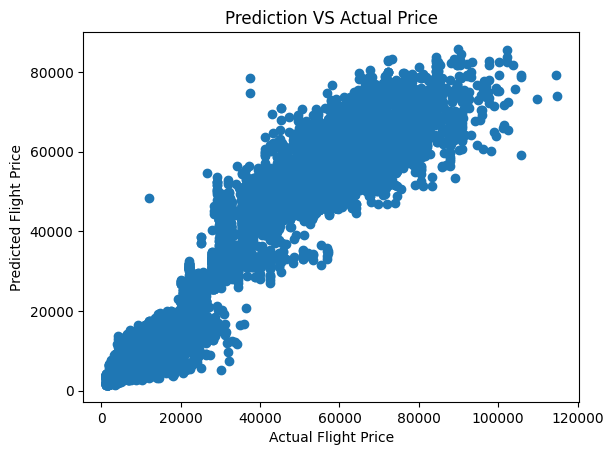

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Price')

In [23]:
importances = dict(zip(X_train.columns, reg.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)
print(sorted_importances)

[('duration', np.int32(826)), ('days_left', np.int32(272)), ('class', np.int32(218)), ('airline_Air_India', np.int32(142)), ('source_Delhi', np.int32(107)), ('source_Kolkata', np.int32(107)), ('dest_Delhi', np.int32(94)), ('dest_Mumbai', np.int32(82)), ('stops', np.int32(80)), ('dest_Hyderabad', np.int32(68)), ('dest_Kolkata', np.int32(68)), ('dest_Chennai', np.int32(65)), ('source_Bangalore', np.int32(60)), ('source_Hyderabad', np.int32(60)), ('source_Chennai', np.int32(59)), ('dest_Bangalore', np.int32(59)), ('departure_Evening', np.int32(54)), ('source_Mumbai', np.int32(52)), ('departure_Afternoon', np.int32(52)), ('arrival_Night', np.int32(49)), ('arrival_Evening', np.int32(47)), ('departure_Early_Morning', np.int32(46)), ('airline_Vistara', np.int32(45)), ('departure_Morning', np.int32(43)), ('arrival_Afternoon', np.int32(40)), ('arrival_Early_Morning', np.int32(39)), ('departure_Night', np.int32(37)), ('airline_Indigo', np.int32(35)), ('airline_AirAsia', np.int32(29)), ('arrival_

<BarContainer object of 10 artists>

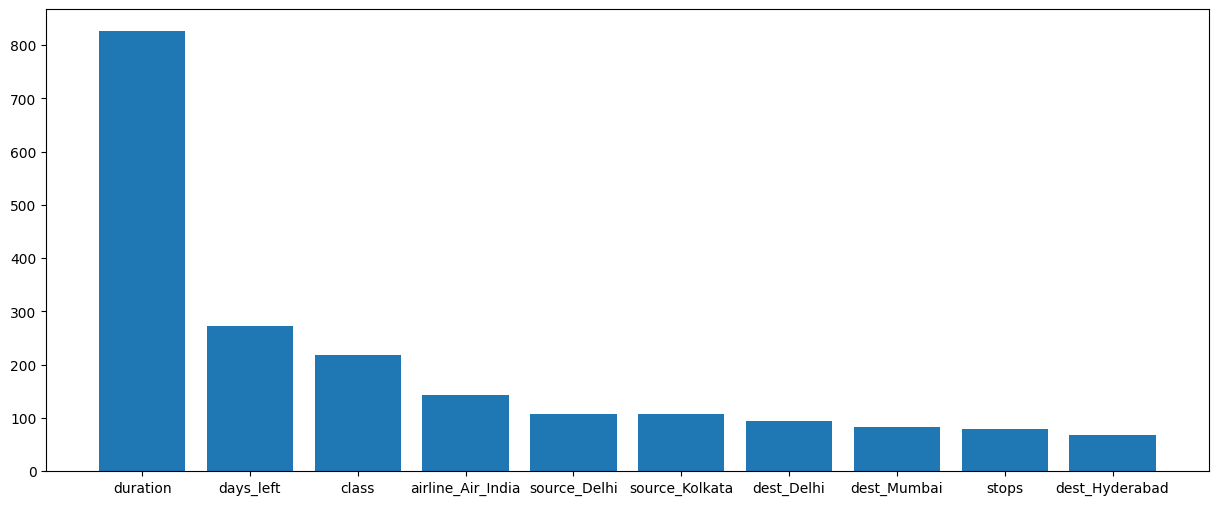

In [24]:
plt.figure(figsize=(15, 6))
plt.bar([x[0] for x in sorted_importances[:10]], [x[1] for x in sorted_importances[:10]])

# Hyperparameter

In [25]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(LGBMRegressor(n_jobs=-1, random_state=42),
                           param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(best_params)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 192097, number of used features: 34
[LightGBM] [Info] Start training from score 20913.595288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 192097, number of used features: 34
[LightGBM] [Info] Start training from score 20950.659802
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

In [29]:
param_dist = {
    'n_estimators': randint(200,400),
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': randint(75,125),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.8, 1.0, 1.2]
}

random_search = RandomizedSearchCV(LGBMRegressor(n_jobs=-1, random_state=42), param_distributions=param_dist, n_iter=2, cv=3, scoring='neg_mean_squared_error', verbose=2, random_state=10, n_jobs=-1)

random_search.fit(X_train, y_train)

best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 34
[LightGBM] [Info] Start training from score 20901.378520


In [36]:
best_regressor.score(X_test, y_test)

0.9871405577408066

In [40]:
y_pred = best_regressor.predict(X_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred)))

R2:  0.9871405577408066
MAE:  1364.5643382184567
MSE:  6598186.849927311
RMSE:  2568.69360763936


Text(0.5, 1.0, 'Prediction VS Actual Price')

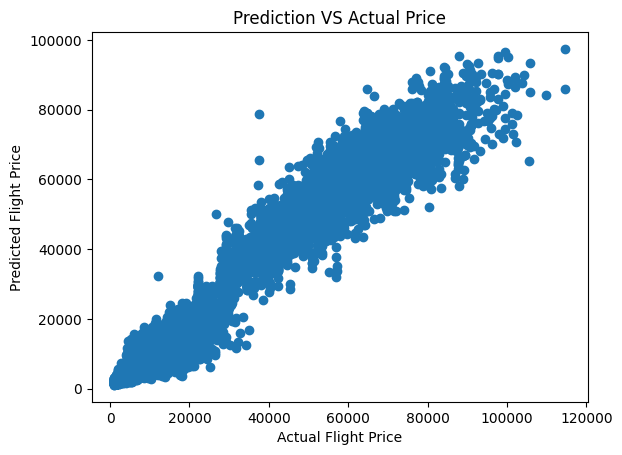

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Price')